In [164]:
from torchvision import datasets
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [165]:
transform = T.ToTensor()
train_ds = datasets.MNIST(root="./data", download=True, transform=transform, train=True)
test_ds = datasets.MNIST(root="./data", download=True, transform=transform, train=False)

In [166]:
X = train_ds.data[:5000].numpy()
y = train_ds.targets[:5000].numpy()

X: np.ndarray = X.reshape(5000, -1)
X = X / 255.0
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

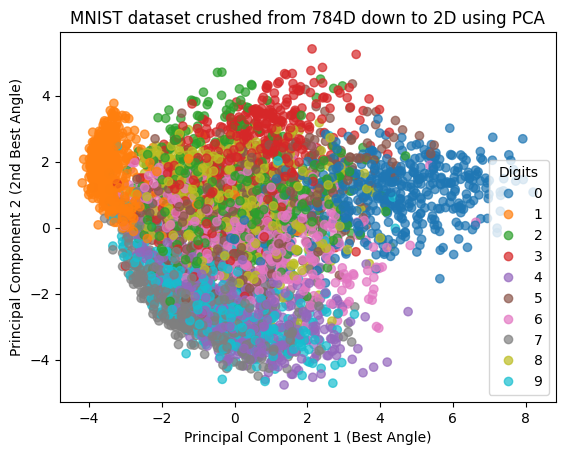

In [167]:
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='tab10', alpha=0.7)
plt.title("MNIST dataset crushed from 784D down to 2D using PCA")
plt.xlabel("Principal Component 1 (Best Angle)")
plt.ylabel("Principal Component 2 (2nd Best Angle)")
# This handy little trick pulls the legend out automatically from your scatter plot
plt.legend(*scatter.legend_elements(), title="Digits")
plt.show()

In [168]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Take the labels (y) and our 2D summary (X_pca) 
# and split them into a training and testing set
split_index = 4000
X_train, X_test = X_pca[:split_index], X_pca[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# 2. Build the exact classifier you just mentioned
clf = DecisionTreeClassifier(max_depth=10, random_state=42)

# 3. Fit it using ONLY the 2 lines of PCA data!
clf.fit(X_train, y_train)

# 4. Predict and see how well it works
predictions = clf.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"{accuracy * 100:.2f}%")


45.70%


In [169]:
kmeans = KMeans(n_clusters=10)
cluster_labels = kmeans.fit_predict(X_psa)

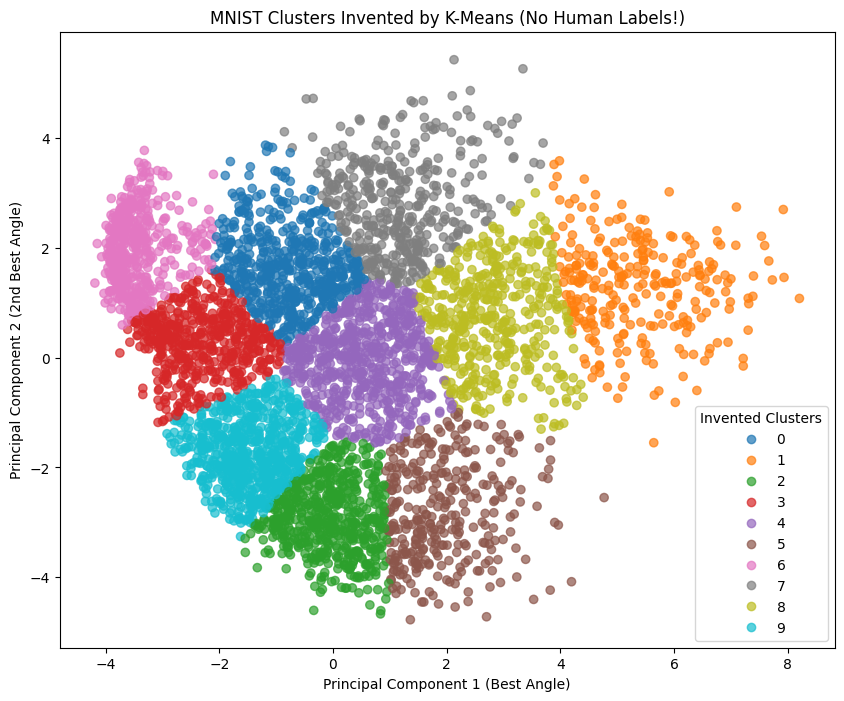

In [170]:
plt.figure(figsize=(10, 8))

# Notice the change here: c=cluster_labels
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.7)

plt.title("MNIST Clusters Invented by K-Means (No Human Labels!)")
plt.xlabel("Principal Component 1 (Best Angle)")
plt.ylabel("Principal Component 2 (2nd Best Angle)")

# This adds a legend matching the colors to the clusters
plt.legend(*scatter.legend_elements(), title="Invented Clusters")

plt.show()
